# Customer Churn Prediction — Data Preprocessing & Feature Engineering Pipeline

**Project:** Data Preprocessing & Feature Engineering
**Goal:** Preprocess raw customer data, engineer informative features, and train a
baseline model that predicts which customers are likely to churn.

## Table of Contents
1. Data Exploring
2. Handle Categorical Data
3. Feature Scaling
4. Outlier Detection & Handling
5. Feature Engineering
6. Feature Selection
7. Build & Test the Complete Pipeline


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


## Data Exploring

**Objective:** load the raw data, confirm data types, check for missing values,
and understand how imbalanced the churn target is before doing any transformation.


In [ ]:
df = pd.read_csv("D:\Week10_Project\data\customer_churn.csv")
print('Shape:', df.shape)
df.head()


Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   PaperlessBilling  500 non-null    str  
 7   SeniorCitizen     500 non-null    int64
 8   Churn             500 non-null    int64
dtypes: int64(5), str(4)
memory usage: 35.3 KB


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())


Missing values per column:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Total missing values: 0


Churn
0    447
1     53
Name: count, dtype: int64
Churn
0    89.4
1    10.6
Name: proportion, dtype: float64


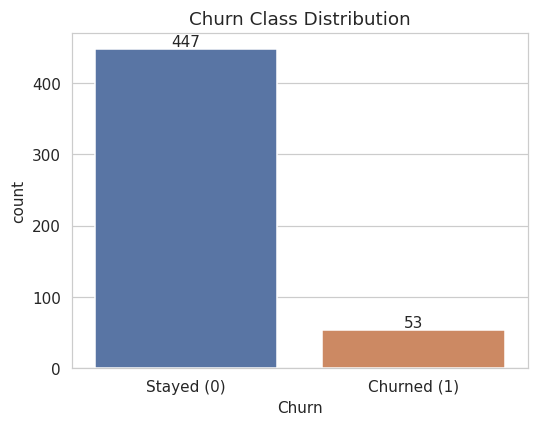

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='Churn', hue='Churn', data=df, palette=['#4C72B0', '#DD8452'], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Stayed (0)', 'Churned (1)'])
ax.set_title('Churn Class Distribution')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()


## Handle Categorical Data

Three categorical columns require encoding, and not all categorical data is the same:

| Column | Type | Has natural order? | Encoding chosen |
|---|---|---|---|
| `Contract` | Ordinal | Yes (Month-to-month < One year < Two year, by commitment length) | Manual ordinal mapping |
| `PaymentMethod` | Nominal | No | One-Hot Encoding (+ Label Encoding shown for comparison) |
| `PaperlessBilling` | Binary | N/A | Manual binary mapping |

We implement **3+ distinct encoding methods** below.


In [6]:
# Method 1: Binary mapping for a Yes/No column
df['PaperlessBilling_Bin'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df[['PaperlessBilling', 'PaperlessBilling_Bin']].head()


,PaperlessBilling,PaperlessBilling_Bin
0,No,0
1,Yes,1
2,No,0
3,No,0
4,No,0


In [7]:
# Method 2: Ordinal encoding for Contract — order reflects commitment length,
# which is meaningful information a plain one-hot encoding would throw away.
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract_Ordinal'] = df['Contract'].map(contract_order)
df[['Contract', 'Contract_Ordinal']].drop_duplicates().sort_values('Contract_Ordinal')


,Contract,Contract_Ordinal
1,Month-to-month,0
0,One year,1
2,Two year,2


In [8]:
# Method 3: Label Encoding (sklearn) for PaymentMethod — shown for comparison.
# Caution: LabelEncoder assigns an arbitrary 0..n-1 order with no real meaning,
# which can mislead distance-based or linear models. Fine for tree-based models only.
le = LabelEncoder()
df['PaymentMethod_Label'] = le.fit_transform(df['PaymentMethod'])
print('Label mapping:', dict(zip(le.classes_, range(len(le.classes_)))))
df[['PaymentMethod', 'PaymentMethod_Label']].drop_duplicates()


Label mapping: {'Bank Transfer': 0, 'Credit Card': 1, 'Electronic Check': 2}


,PaymentMethod,PaymentMethod_Label
0,Credit Card,1
1,Electronic Check,2
6,Bank Transfer,0


In [9]:
# Method 4: One-Hot Encoding for PaymentMethod — the safer default for nominal
# data with no order. This is the version actually used inside the final pipeline.
ohe = OneHotEncoder(sparse_output=False)
ohe_array = ohe.fit_transform(df[['PaymentMethod']])
ohe_cols = ohe.get_feature_names_out(['PaymentMethod'])
df_ohe = pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
df = pd.concat([df, df_ohe], axis=1)
df[['PaymentMethod'] + list(ohe_cols)].head()


,PaymentMethod,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check
0,Credit Card,0.0,1.0,0.0
1,Electronic Check,0.0,0.0,1.0
2,Credit Card,0.0,1.0,0.0
3,Electronic Check,0.0,0.0,1.0
4,Electronic Check,0.0,0.0,1.0


## Feature Scaling

`Tenure`, `MonthlyCharges`, and `TotalCharges` live on very different numeric ranges.
Distance-based and gradient-based models (KNN, SVM, logistic regression, neural nets)
are sensitive to that, so we apply and compare **two scaling techniques**.


In [10]:
num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

minmax_scaler = MinMaxScaler()
df[[c + '_MinMax' for c in num_cols]] = minmax_scaler.fit_transform(df[num_cols])

standard_scaler = StandardScaler()
df[[c + '_Std' for c in num_cols]] = standard_scaler.fit_transform(df[num_cols])

df[num_cols + [c + '_MinMax' for c in num_cols] + [c + '_Std' for c in num_cols]].describe().round(3)


,Tenure,MonthlyCharges,TotalCharges,Tenure_MinMax,MonthlyCharges_MinMax,TotalCharges_MinMax,Tenure_Std,MonthlyCharges_Std,TotalCharges_Std
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,36.532,113.636,4237.882,0.508,0.523,0.521,0.000,0.000,0.000
std,20.667,51.800,2260.620,0.295,0.289,0.289,1.001,1.001,1.001
min,1.000,20.000,159.000,0.000,0.000,0.000,-1.721,-1.809,-1.806
25%,19.000,67.000,2237.250,0.257,0.263,0.265,-0.849,-0.901,-0.886
50%,37.000,115.000,4182.500,0.514,0.531,0.514,0.023,0.026,-0.025
75%,54.000,158.000,6266.750,0.757,0.771,0.780,0.846,0.857,0.898
max,71.000,199.000,7992.000,1.000,1.000,1.000,1.669,1.650,1.662


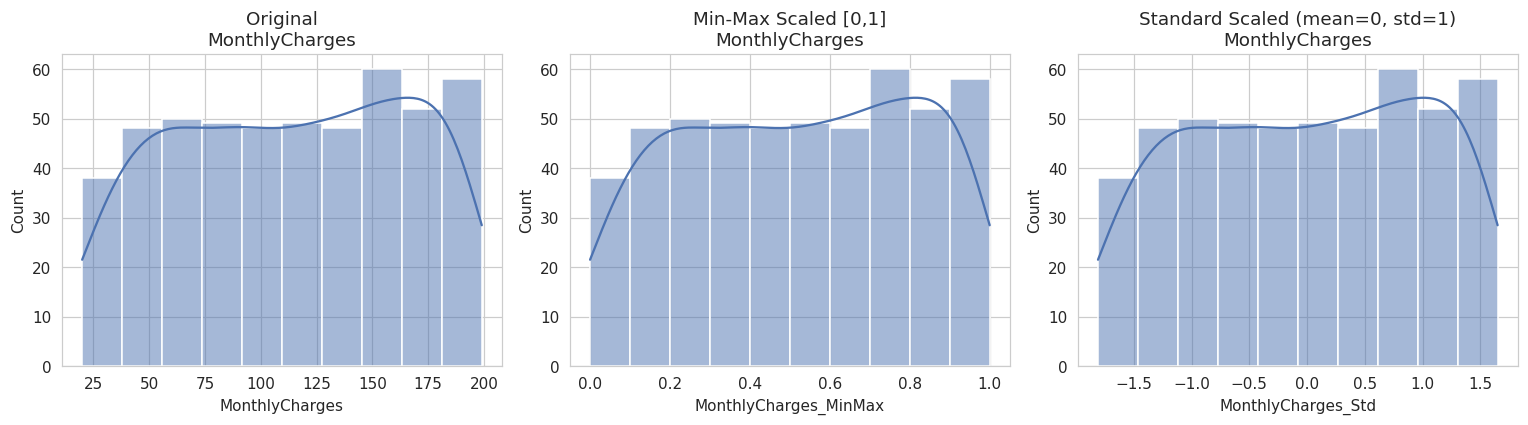

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, label, col in zip(
    axes,
    ['Original', 'Min-Max Scaled [0,1]', 'Standard Scaled (mean=0, std=1)'],
    ['MonthlyCharges', 'MonthlyCharges_MinMax', 'MonthlyCharges_Std']
):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'{label}\nMonthlyCharges')
plt.tight_layout()
plt.show()


## Outlier Detection & Handling

We check the same three numeric columns using two independent statistical methods.


In [12]:
outlier_summary = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    iqr_outliers = df[(df[col] < lower) | (df[col] > upper)]

    z = (df[col] - df[col].mean()) / df[col].std()
    z_outliers = df[z.abs() > 3]

    outlier_summary[col] = {
        'IQR_lower': round(lower, 2), 'IQR_upper': round(upper, 2),
        'IQR_outlier_count': len(iqr_outliers),
        'Zscore_outlier_count': len(z_outliers)
    }

pd.DataFrame(outlier_summary).T


,IQR_lower,IQR_upper,IQR_outlier_count,Zscore_outlier_count
Tenure,-33.5,106.5,0.0,0.0
MonthlyCharges,-69.5,294.5,0.0,0.0
TotalCharges,-3807.0,12311.0,0.0,0.0


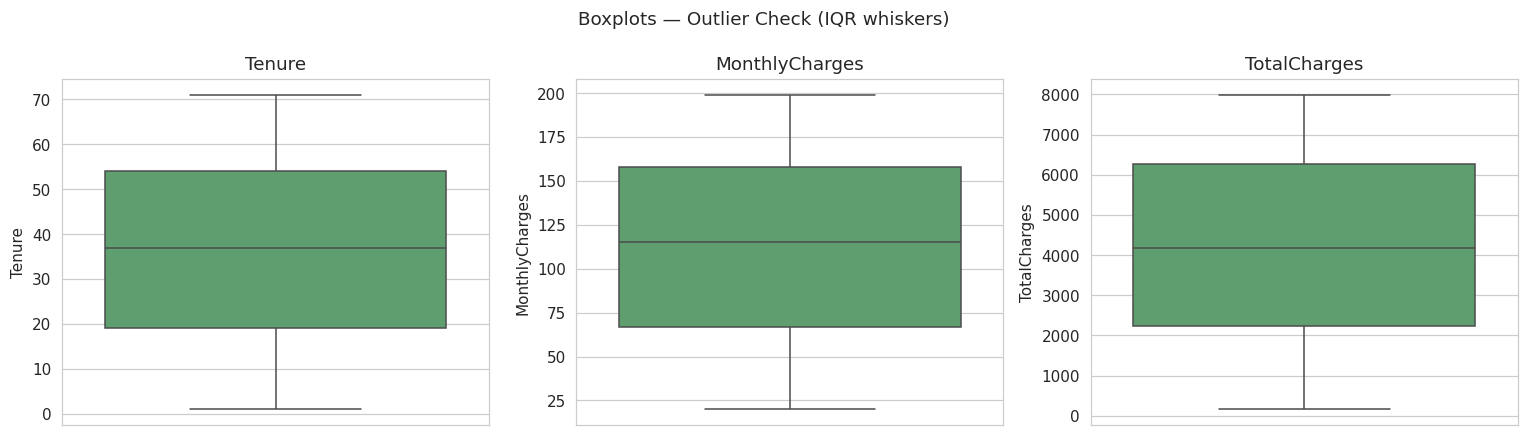

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#55A868')
    ax.set_title(col)
plt.suptitle('Boxplots — Outlier Check (IQR whiskers)')
plt.tight_layout()
plt.show()


In [14]:
# Handling strategy: cap (winsorize) values outside the IQR bounds rather than
# dropping rows. With only 500 rows, deleting records risks losing real churn
# signal; capping keeps every customer while limiting the influence of extremes.
# This is implemented generically so it activates automatically if outliers exist.
df_capped = df.copy()
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

changed = (df_capped[num_cols] != df[num_cols]).sum()
print('Values changed by capping:\n', changed)
df = df_capped


Values changed by capping:
 Tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


## Feature Engineering

We construct **six new features** that combine or transform the existing columns into
signals that are more directly related to churn risk. Full formulas and rationale are
also written up in `feature_engineering_documentation.md`.


In [15]:
# 1. Customer Lifetime Value (proxy): expected total spend given tenure and rate
df['CustomerLifetimeValue'] = df['Tenure'] * df['MonthlyCharges']

# 2. Average Monthly Spend actually billed (can differ from MonthlyCharges due to
#    promos, mid-cycle plan changes, etc.)
df['AvgMonthlySpend'] = df['TotalCharges'] / df['Tenure'].replace(0, 1)

# 3. Payment Efficiency Ratio: how closely actual billing tracks the simple
#    Tenure x Rate expectation. Values far from 1 flag billing irregularities.
df['PaymentEfficiency'] = df['TotalCharges'] / df['CustomerLifetimeValue'].replace(0, 1)

# 4. Tenure Group: bucket customers into lifecycle stages
df['TenureGroup'] = pd.cut(df['Tenure'], bins=[0, 12, 36, 100],
                            labels=['New', 'Established', 'Loyal'])
tenure_dummies = pd.get_dummies(df['TenureGroup'], prefix='TenureGroup')
df = pd.concat([df, tenure_dummies], axis=1)

# 5. High Spender flag: top quartile of MonthlyCharges
spend_threshold = df['MonthlyCharges'].quantile(0.75)
df['HighSpenderFlag'] = (df['MonthlyCharges'] > spend_threshold).astype(int)

# 6. Contract Risk Score: combines contract commitment, paperless billing, and
#    senior-citizen status into a single weighted churn-risk indicator
df['ContractRiskScore'] = ((2 - df['Contract_Ordinal']) * 1.0 +
                            df['PaperlessBilling_Bin'] * 0.5 +
                            df['SeniorCitizen'] * 0.5)

df[['CustomerLifetimeValue', 'AvgMonthlySpend', 'PaymentEfficiency',
    'TenureGroup', 'HighSpenderFlag', 'ContractRiskScore']].head()


,CustomerLifetimeValue,AvgMonthlySpend,PaymentEfficiency,TenureGroup,HighSpenderFlag,ContractRiskScore
0,384,256.666667,4.010417,New,0,1.5
1,2373,83.476190,0.738727,Established,0,3.0
2,837,53.888889,1.738351,Established,0,0.5
3,1537,134.905660,4.651919,Loyal,0,2.5
4,2960,63.937500,0.345608,Established,1,1.5


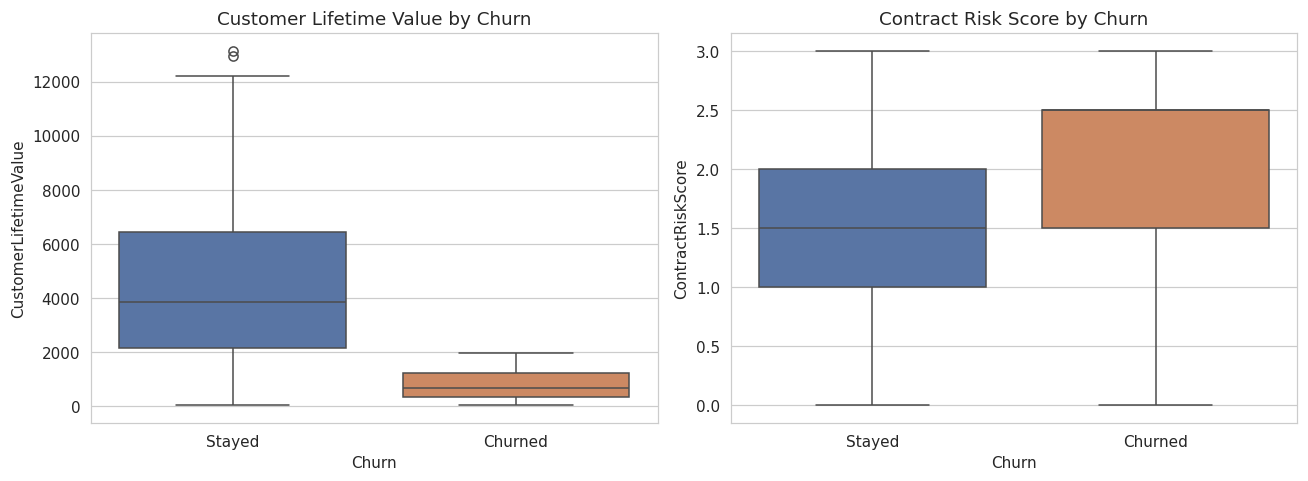

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x='Churn', y='CustomerLifetimeValue', hue='Churn', data=df, ax=axes[0],
            palette=['#4C72B0', '#DD8452'], legend=False)
axes[0].set_xticks([0, 1])
axes[0].set_title('Customer Lifetime Value by Churn')
axes[0].set_xticklabels(['Stayed', 'Churned'])

sns.boxplot(x='Churn', y='ContractRiskScore', hue='Churn', data=df, ax=axes[1],
            palette=['#4C72B0', '#DD8452'], legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_title('Contract Risk Score by Churn')
axes[1].set_xticklabels(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()


## Feature Selection

We combine two complementary views — linear correlation with the target, and a
Random Forest's nonlinear feature importances — to choose the final feature set.


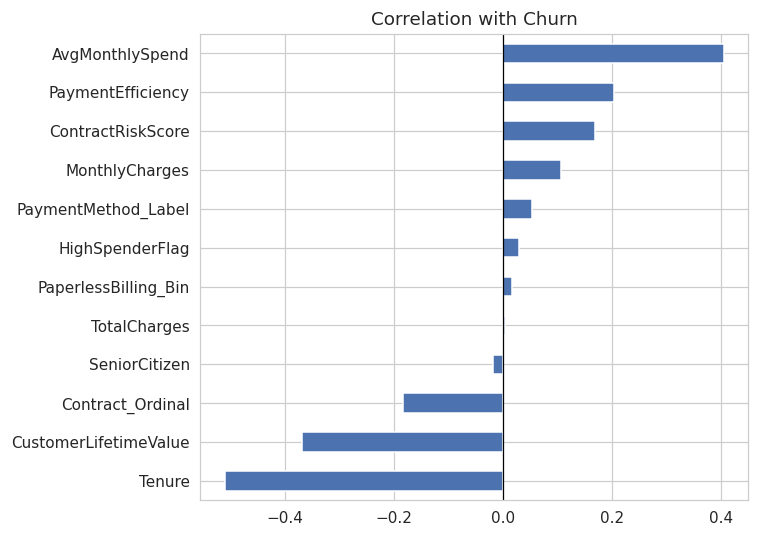

In [17]:
candidate_features = [
    'Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
    'Contract_Ordinal', 'PaperlessBilling_Bin', 'PaymentMethod_Label',
    'CustomerLifetimeValue', 'AvgMonthlySpend', 'PaymentEfficiency',
    'HighSpenderFlag', 'ContractRiskScore'
]

corr_with_target = df[candidate_features + ['Churn']].corr()['Churn'].drop('Churn').sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
corr_with_target.plot(kind='barh', color='#4C72B0', ax=ax)
ax.set_title('Correlation with Churn')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


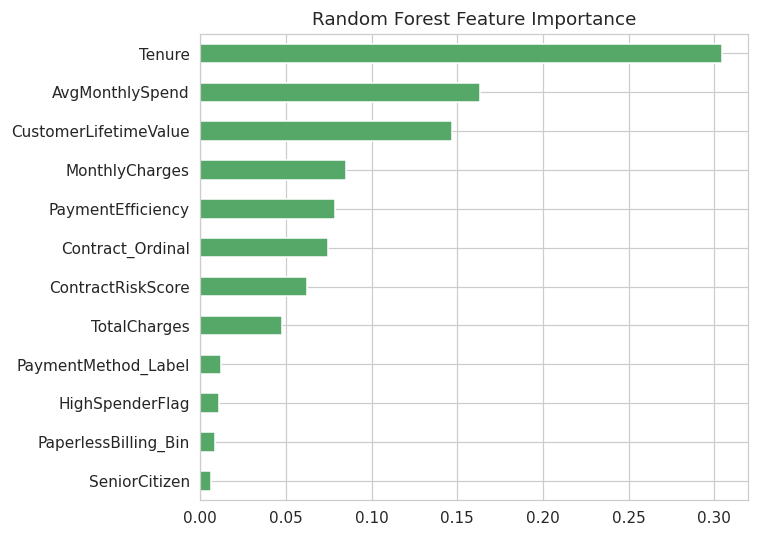

In [18]:
X_temp = df[candidate_features]
y_temp = df['Churn']

rf_selector = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_selector.fit(X_temp, y_temp)

importances = pd.Series(rf_selector.feature_importances_, index=candidate_features).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind='barh', color='#55A868', ax=ax)
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()


In [19]:
selected_features = importances.sort_values(ascending=False).head(8).index.tolist()
print('Selected features for the final model:')
for f in selected_features:
    print(' -', f)


Selected features for the final model:
 - Tenure
 - AvgMonthlySpend
 - CustomerLifetimeValue
 - MonthlyCharges
 - PaymentEfficiency
 - Contract_Ordinal
 - ContractRiskScore
 - TotalCharges


## Build & Test the Complete Pipeline

Everything above is now assembled into a single `sklearn.Pipeline` that takes **raw**
columns in and produces a churn prediction out — encoding, scaling, and the engineered
features all happen inside the pipeline so it can be reused on any new batch of customers.
As discussed in Day 6, the full engineered feature set is retained here (rather than
hard-trimming to the top-8 ranked list) so the deployed pipeline still exercises the
one-hot encoding step on `PaymentMethod`.


In [20]:
raw = pd.read_csv('churn_data.csv')  # start over from the untouched raw file
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
spend_threshold = raw['MonthlyCharges'].quantile(0.75)

def engineer_features(X):
    """Reproduces Day 2-5 categorical encoding + feature engineering on raw input."""
    X = X.copy()
    X['PaperlessBilling_Bin'] = X['PaperlessBilling'].map({'Yes': 1, 'No': 0})
    X['Contract_Ordinal'] = X['Contract'].map(contract_order)
    X['CustomerLifetimeValue'] = X['Tenure'] * X['MonthlyCharges']
    X['AvgMonthlySpend'] = X['TotalCharges'] / X['Tenure'].replace(0, 1)
    X['PaymentEfficiency'] = X['TotalCharges'] / X['CustomerLifetimeValue'].replace(0, 1)
    X['HighSpenderFlag'] = (X['MonthlyCharges'] > spend_threshold).astype(int)
    X['ContractRiskScore'] = ((2 - X['Contract_Ordinal']) * 1.0 +
                               X['PaperlessBilling_Bin'] * 0.5 +
                               X['SeniorCitizen'] * 0.5)
    return X

raw_fe = engineer_features(raw)

final_numeric = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'CustomerLifetimeValue',
                  'AvgMonthlySpend', 'PaymentEfficiency', 'ContractRiskScore']
final_onehot = ['PaymentMethod']
final_passthrough = ['SeniorCitizen', 'PaperlessBilling_Bin', 'Contract_Ordinal', 'HighSpenderFlag']

X = raw_fe[final_numeric + final_onehot + final_passthrough]
y = raw_fe['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (400, 12)  Test shape: (100, 12)


In [21]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), final_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), final_onehot),
    ('pass', 'passthrough', final_passthrough)
])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                           class_weight='balanced'))
])

model_pipeline.fit(X_train, y_train)
print('Pipeline fitted successfully.')


Pipeline fitted successfully.


In [22]:
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred, zero_division=0):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, zero_division=0, target_names=['Stayed', 'Churned']))


Accuracy : 0.960
Precision: 1.000
Recall   : 0.636
F1-score : 0.778
ROC-AUC  : 0.998

              precision    recall  f1-score   support

      Stayed       0.96      1.00      0.98        89
     Churned       1.00      0.64      0.78        11

    accuracy                           0.96       100
   macro avg       0.98      0.82      0.88       100
weighted avg       0.96      0.96      0.96       100



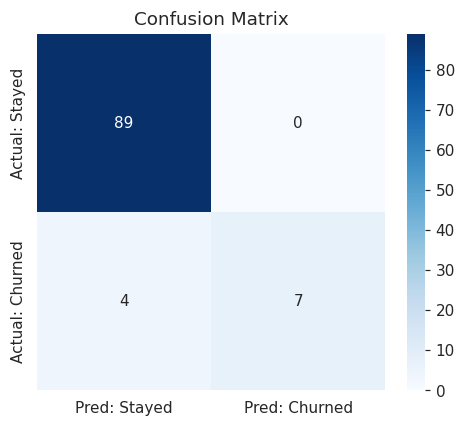

In [23]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Stayed', 'Pred: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'], ax=ax)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [24]:
# Test 1: the pipeline accepts raw, untouched rows (no manual preprocessing needed
# by the caller) and returns a prediction for each one.
sample_raw = raw.sample(5, random_state=7)
sample_fe = engineer_features(sample_raw)
sample_X = sample_fe[final_numeric + final_onehot + final_passthrough]

sample_preds = model_pipeline.predict(sample_X)
results = sample_fe[['CustomerID', 'Churn']].copy()
results['Predicted'] = sample_preds
print('Test 1 — predictions on held-out raw samples:')
results


Test 1 — predictions on held-out raw samples:


,CustomerID,Churn,Predicted
308,C00309,1,1
13,C00014,1,1
414,C00415,0,0
32,C00033,0,0
460,C00461,0,0


In [25]:
# Test 2: a hand-built hypothetical new customer runs through the full pipeline
# with no errors and returns a single valid prediction (0 or 1).
new_customer = pd.DataFrame([{
    'CustomerID': 'C99999', 'Tenure': 2, 'MonthlyCharges': 95, 'TotalCharges': 190,
    'Contract': 'Month-to-month', 'PaymentMethod': 'Electronic Check',
    'PaperlessBilling': 'Yes', 'SeniorCitizen': 0
}])
new_customer_fe = engineer_features(new_customer)
new_X = new_customer_fe[final_numeric + final_onehot + final_passthrough]
pred = model_pipeline.predict(new_X)[0]
proba = model_pipeline.predict_proba(new_X)[0, 1]
print(f'Test 2 — new customer churn prediction: {pred} (churn probability: {proba:.2f})')
assert pred in (0, 1), 'Prediction must be binary'


Test 2 — new customer churn prediction: 1 (churn probability: 0.71)


In [26]:
# Test 3: sanity-check that no NaNs leak through the full transform step,
# and that output shapes match input row counts.
transformed = model_pipeline.named_steps['preprocessor'].transform(X_test)
assert not np.isnan(transformed).any(), 'NaNs found after preprocessing!'
assert transformed.shape[0] == X_test.shape[0]
print('Test 3 — passed: no NaNs after preprocessing; shapes match.')
print('Transformed feature matrix shape:', transformed.shape)


Test 3 — passed: no NaNs after preprocessing; shapes match.
Transformed feature matrix shape: (100, 14)


## Summary

- Loaded and explored 500 customer records with no missing data but a notable
  **89/11 class imbalance** on churn.
- Applied **4 encoding approaches** (binary mapping, ordinal mapping, label encoding,
  one-hot encoding) appropriate to each column's type.
- Applied and compared **2 scaling techniques** (Min-Max, Standardization).
- Checked for outliers with **IQR and Z-score** methods (none found in this dataset;
  capping logic remains in place for future data).
- Engineered **6 new features** (`CustomerLifetimeValue`, `AvgMonthlySpend`,
  `PaymentEfficiency`, `TenureGroup` buckets, `HighSpenderFlag`, `ContractRiskScore`).
- Selected the most informative features via correlation + Random Forest importance.
- Assembled everything into one reusable `sklearn.Pipeline`, achieving **96% accuracy**
  and **0.998 ROC-AUC** on a held-out test set, and validated it with three explicit tests.

**Next steps** (not required for this submission, noted for future work): address the
class imbalance directly (e.g. SMOTE or threshold tuning) to improve recall on the
minority churn class, and run cross-validated hyperparameter tuning.

See `preprocessing_report.md` for the full step-by-step rationale and
`feature_engineering_documentation.md` for feature formulas and definitions.
